### **Hippo Pathway Model: Contact inhibition and YAP regulation through the MST/LATS signaling cascade**

##### This model represents the Hippo pathway, where increased cell density activates MST and LATS, leading to YAP phosphorylation, cytoplasmic sequestration, and reduced YAP–TEAD transcriptional activity.

In [21]:
from molclustpy import * # imports BNG_multiTrials, NFSim_output_analyzer, and different visualization functions 

In [13]:
# bngl file (BioNetGen model) 
# the bngl file location is currently same as the notebook; i.e., you have to place the bngl file in the 
# same directory with the notebook

bng_file = 'contact-inhibition-hippo-yap_mcp.bngl'

# Initialization of the Simulation Object
simObj = BNG_multiTrials(bng_file, t_end=0.02, steps=20, numRuns=20)
print(simObj)
simObj.runTrials(delSim=False)
print()


***** // ***** 
Class : BNG_multiTrials
File Path : contact-inhibition-hippo-yap_mcp.bngl

t_end : 0.02 seconds 	 output_steps : 20
Number of runs: 20

Molecules: ['Contact', 'LATS', 'MST', 'TEAD', 'YAP']
Number of binding sites: [1, 1, 1, 2, 3]
Species Counts: [1000.0, 200.0, 200.0, 500.0, 150.0]

NFsim progress : [****************************************] 100%
Execution time : 13.3267 seconds



In [14]:
# analyze data across multiple trials
outpath = simObj.getOutPath()
molecules, numSite, counts, _ = simObj.getMolecules()
nfsObj = NFSim_output_analyzer(outpath)
print(nfsObj)
nfsObj.process_gdatfiles()
nfsObj.process_speciesfiles(molecules, counts, numSite)


***** // ***** 
Class : NFSim_output_analyzer
System : contact-inhibition-hippo-yap_mcp
Total Trajectories : 20

Processing gdat_files : [****************************************] 100%

Observables:  {0: 'time', 1: 'Transcript_Active', 2: 'YAP_Sequested', 3: 'Active_LATS', 4: 'MST_Trigger', 5: 'Nuclear_YAP', 6: 'Active_MST'}

Processing species_files : [****************************************] 100%


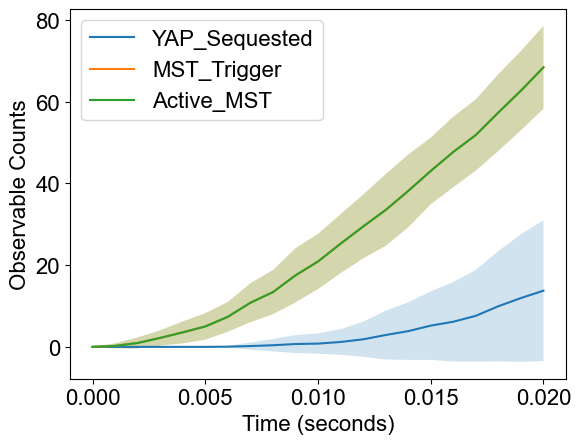

In [15]:
# indexList for observables
plotTimeCourse(outpath, obsList=[2,4,6])

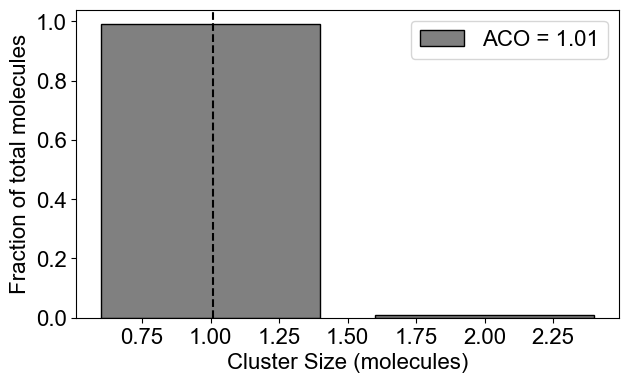

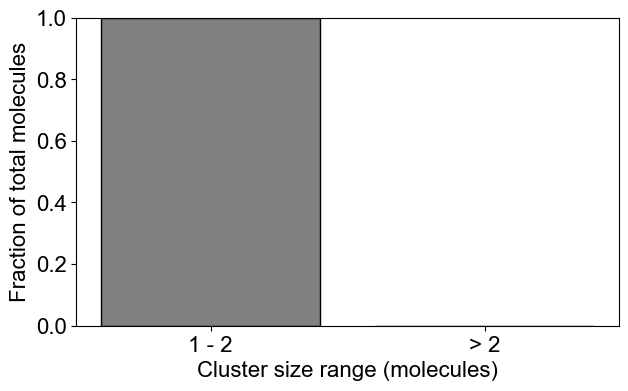

In [16]:
# 2A: Cluster size distribution (ACO: Average Cluster Occupancy)
plotClusterDist(outpath)
# Binned distribution by providing cluster size ranges
plotClusterDist(outpath, sizeRange=[1,2])

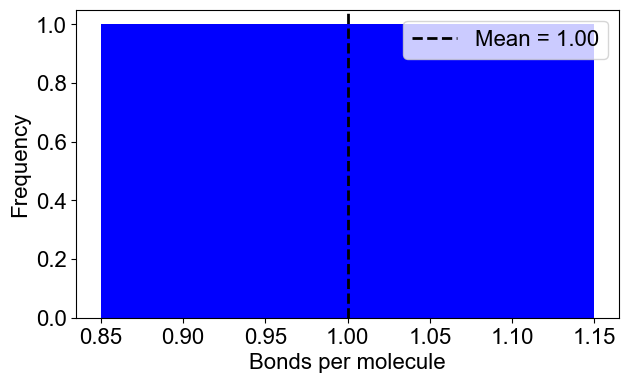

In [17]:
# 2B: Number of bonds per molecule
plotBondsPerMolecule(outpath)

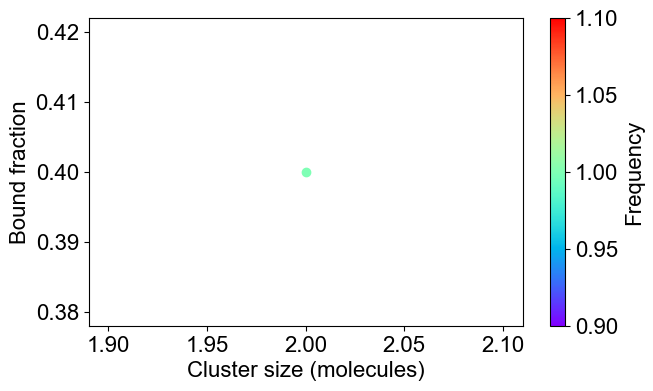

In [18]:
# 2C: Bound fraction distribution
plotBoundFraction(outpath)

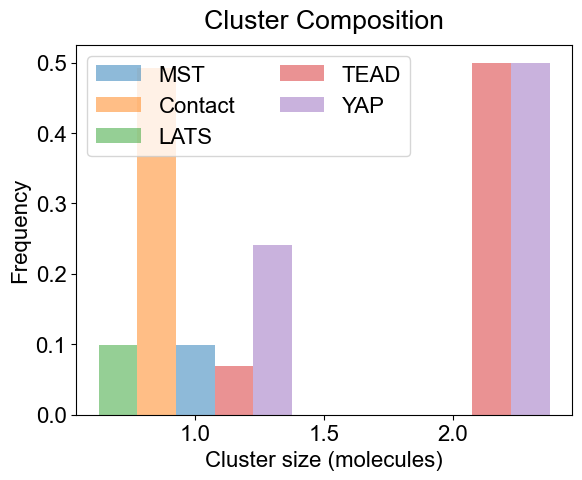

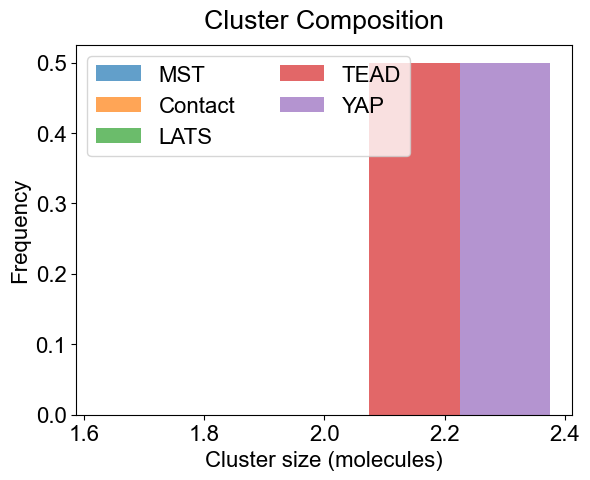

In [19]:
# 3A. Average composition of indivual clusters. 
# Default is all the clusters present in the system. As before, adjust width and transparency (alpha) for visual clarity.
plotClusterComposition(outpath, specialClusters=[], width=0.15, alpha=0.5)

# You can look at the composition of a set of clusters (specialClusters) also
plotClusterComposition(outpath, specialClusters=[2, 4, 10], width=0.15, alpha=0.7)

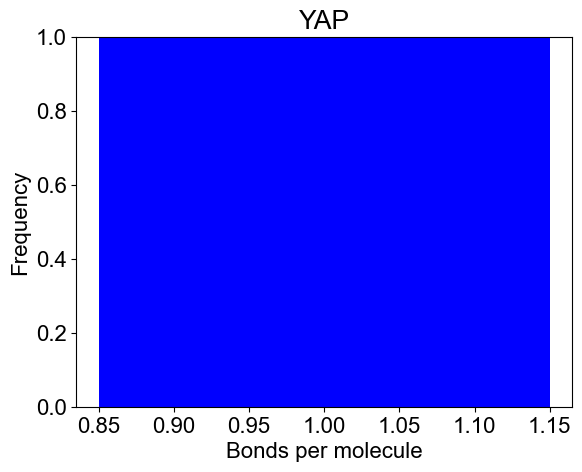

In [20]:
# 3B. Bondcount distribution of each molecular type 
# plotBondCounts(outpath, molecules=molecules) # Reading molecules from previous block

# You may provide a subset of molecules also
plotBondCounts(outpath, molecules=['YAP'])